In [4]:
import pandas as pd
import shap
import sklearn
import xgboost
from sklearn.neural_network import MLPRegressor

In [17]:
df = pd.read_csv("train.csv")
df.dropna(axis=0, subset=["SalePrice"], inplace=True)
y = df.SalePrice
X = df.drop(["SalePrice"], axis=1).select_dtypes(exclude=["object"])

In [18]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.3, random_state=7
)
X_background = shap.utils.sample(X_train, nsamples=500, random_state=7)

In [31]:
xgb_mod = xgboost.XGBRegressor(random_state=7).fit(X_train, y_train)

In [32]:
y_pred = xgb_mod.predict(X_test)
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mae)

Mean Squared Error: 20255.67578125


In [58]:
explainer = shap.Explainer(xgb_mod.predict, X)
xgb_shap_values = explainer(X)

PermutationExplainer explainer: 1461it [00:19, 37.12it/s]                          


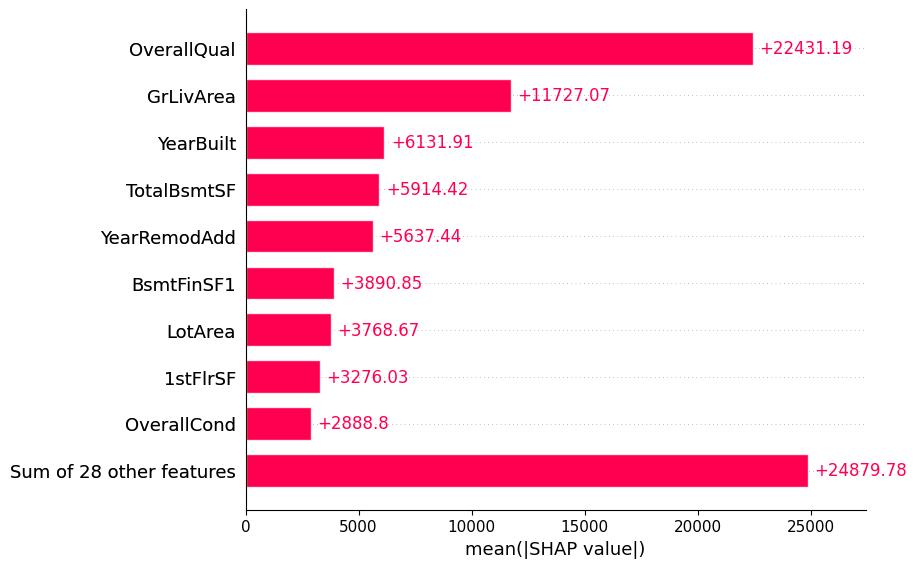

In [59]:
shap.plots.bar(xgb_shap_values)

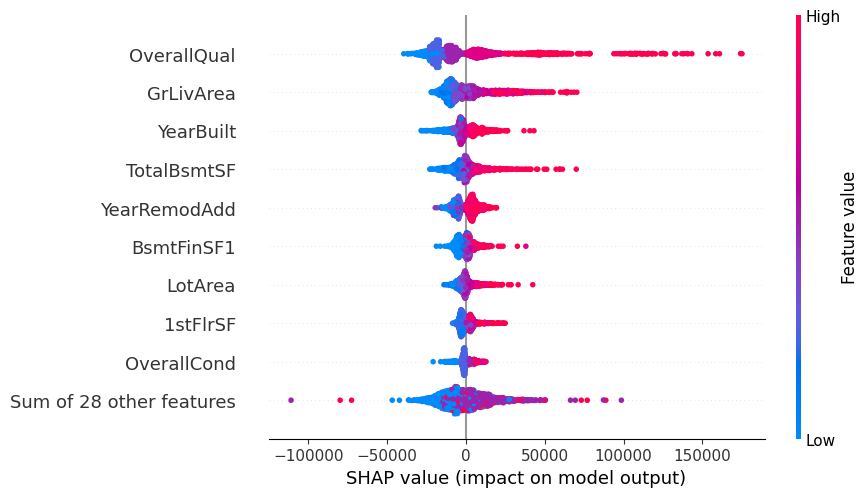

In [60]:
shap.plots.beeswarm(xgb_shap_values)

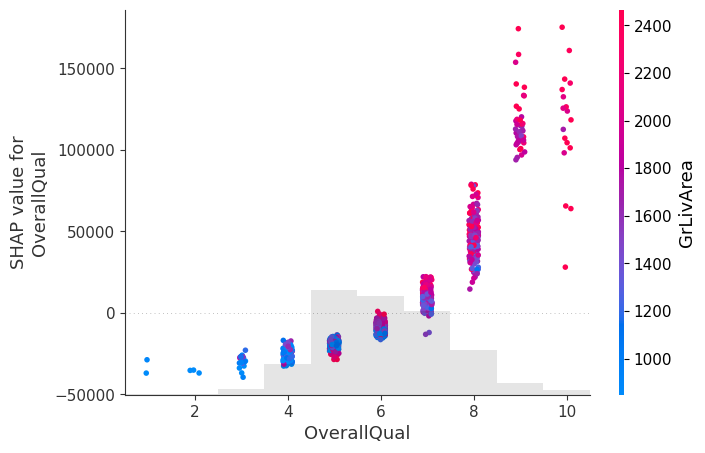

In [61]:
shap.plots.scatter(xgb_shap_values[:, "OverallQual"], color=xgb_shap_values[:, "GrLivArea"])

In [54]:
rf_mod = sklearn.ensemble.RandomForestRegressor(random_state=7).fit(X_train, y_train)
y_pred = rf_mod.predict(X_test)
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Squared Error: 921156240.5930622
Mean Absolute Error: 18151.513972602737


In [56]:
explainer = shap.Explainer(rf_mod.predict, X)
rf_shap_values = explainer(X)

PermutationExplainer explainer: 1461it [02:36,  8.75it/s]                          


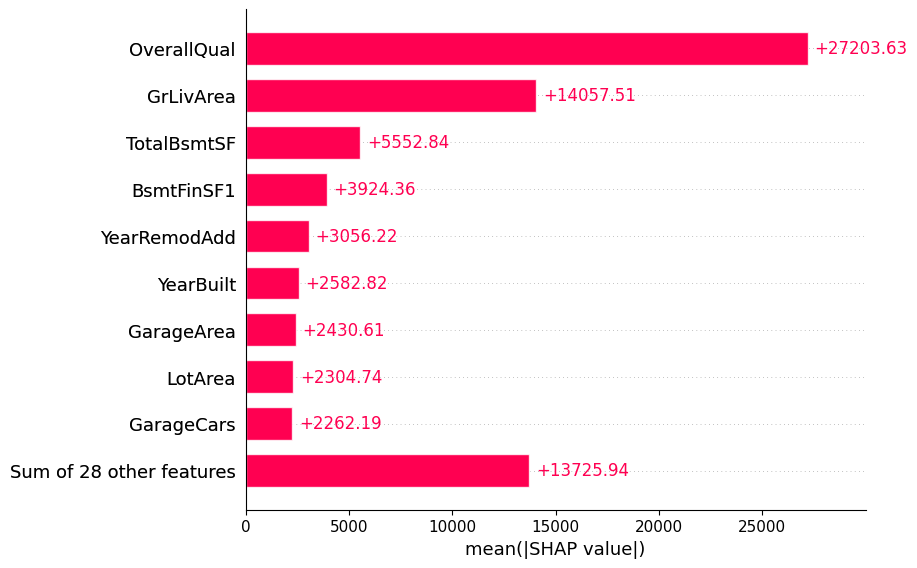

In [57]:
shap.plots.bar(rf_shap_values)

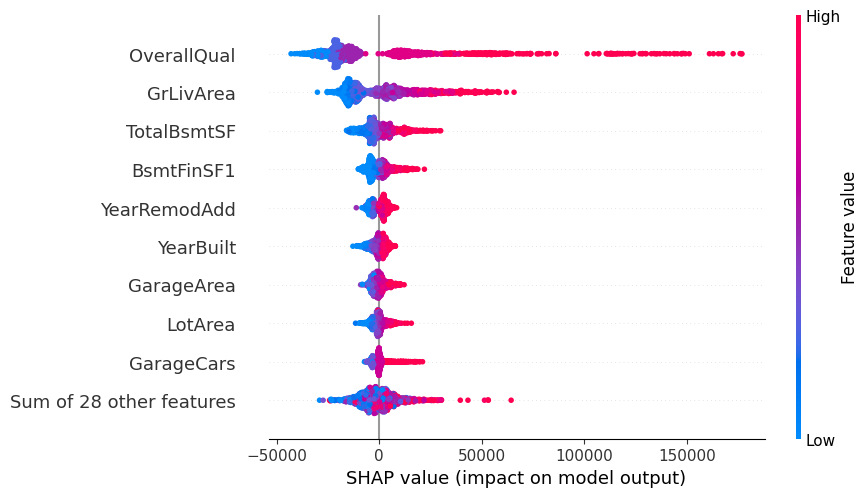

In [63]:
shap.plots.beeswarm(rf_shap_values)

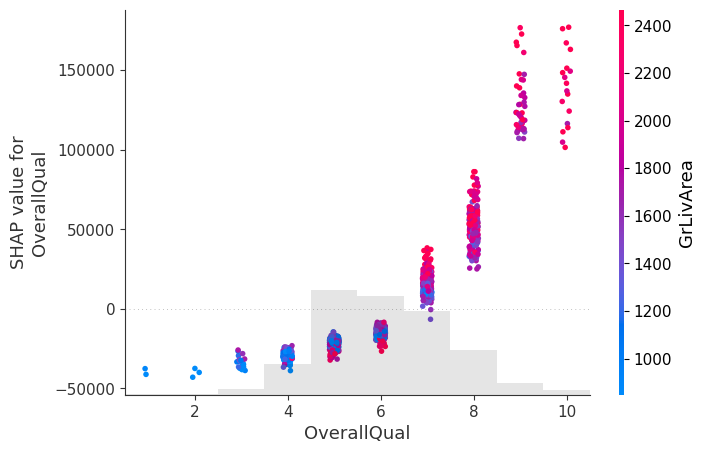

In [64]:
shap.plots.scatter(rf_shap_values[:, "OverallQual"], color=rf_shap_values[:, "GrLivArea"])

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [73]:
pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(20, 20), max_iter=10000),
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [74]:
mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Squared Error: 2088330374.6485038
Mean Absolute Error: 23120.632917153194


In [77]:
explainer = shap.Explainer(pipeline.predict, X)
nn_shap_values = explainer(X)

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: d

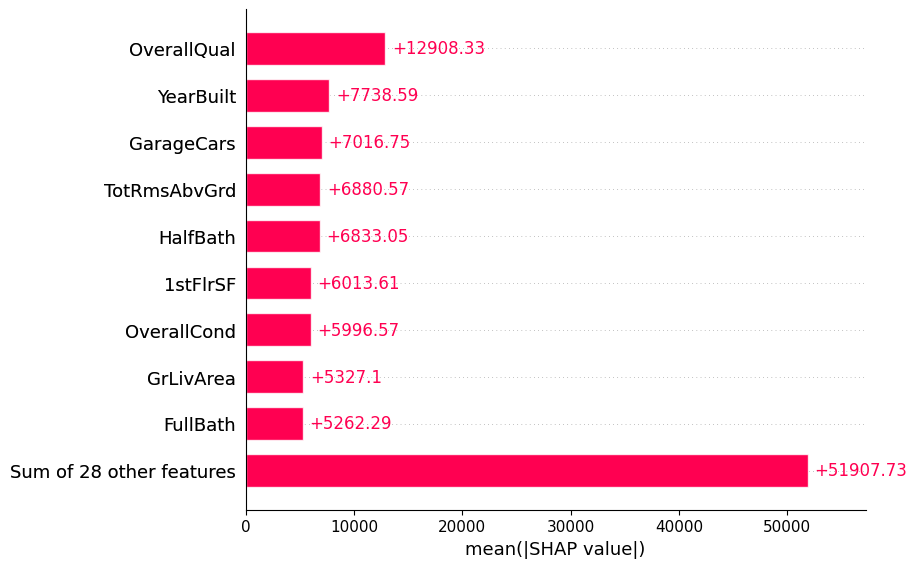

In [78]:
shap.plots.bar(nn_shap_values)

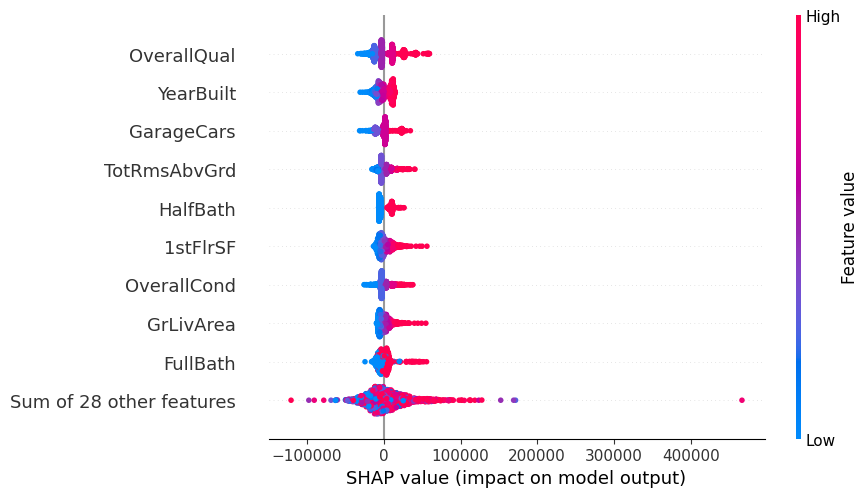

In [79]:
shap.plots.beeswarm(nn_shap_values)

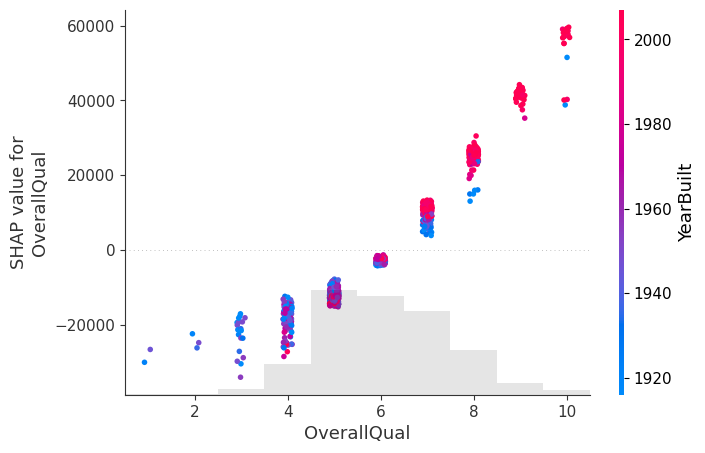

In [81]:
(shap.plots.scatter(nn_shap_values[:, "OverallQual"], color=nn_shap_values[:, "YearBuilt"]))